# 04 · Shot-noise robustness

**Computes.** With exact expectations replaced by $N$-shot estimates, $N\in\{10,10^2,10^3,10^4\}$, the Owen estimator stays **unbiased**: its MAE, cosine, and Spearman rank correlation against the exact Shapley values improve as $1/\sqrt N$ for **both** the feature game (Iris QNN, $d=4$) and the gate game (\texttt{qshaptools} QAOA, $m=13$). The exactness is a property of the estimator, not of noiseless simulation. Feature shots are Binomial draws on the readout probability; gate shots are measurement samples of the channel-mixture energy.

**Produces.** `figures/fig_shots.png` (paper panel (c)) and `results/04.json`.

**Seed.** Fixed: shot RNG seeds 0..$R-1$ averaged at each $N$.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import matplotlib.pyplot as plt
import tnshapq as T
from tnshapq import datasets, exact, owen, metrics
from tnshapq.io_utils import save_results, savefig

np.random.seed(0)
plt.rcParams.update({'font.size': 13, 'axes.titlesize': 13, 'axes.labelsize': 13,
                     'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 11})
SHOTS = [10, 100, 1000, 10000]
R = 24                          # repeats per shot budget (seeds 0..R-1), averaged

In [2]:
# Feature game (Iris d=4): exact on/off probs precomputed once, then binomial shots
D = 4; Mf = T.threshold_M(D, 1)
X, y, baseline, qnn, acc = datasets.iris_qnn(D)
cohort = datasets.pick_instances(X, 4, seed=123)
feat_exact, feat_probs = [], []
for idx, x in cohort:
    tab = exact.feature_value_table(qnn, D, x, baseline)
    feat_exact.append(exact.exact_shapley(tab, D))
    t, w, on, off = owen.precompute_marginal_probs(qnn, D, x, baseline, Mf)
    feat_probs.append((on, off, w))
print(f"feature game ready: d={D}, M={Mf}, {len(cohort)} instances, acc={acc:.3f}")

feature game ready: d=4, M=2, 4 instances, acc=0.970


In [3]:
# Gate game (QAOA m=13): exact channel-mixture Shapley as ground truth
qc, H, game = T.build_qaoa_example()
Mg = T.threshold_M(game.n, 1)
gate_exact = exact.exact_shapley(exact.exact_value_table(game), game.n)
print(f"gate game ready: m={game.n}, M={Mg}, exact Shapley computed")

gate game ready: m=13, M=7, exact Shapley computed


In [4]:
# Sweep shot budgets; average MAE / cosine / Spearman over R seeds
def stats(est_list, exact_vecs):
    maes = [metrics.mae(e, x) for e, x in zip(est_list, exact_vecs)]
    coss = [metrics.cosine(e, x) for e, x in zip(est_list, exact_vecs)]
    sps  = [metrics.spearman(e, x) for e, x in zip(est_list, exact_vecs)]
    return float(np.mean(maes)), float(np.mean(coss)), float(np.mean(sps))

feat = {"mae": [], "cos": [], "sp": []}
gate = {"mae": [], "cos": [], "sp": []}
for N in SHOTS:
    fe, fx, ge, gx = [], [], [], []
    for s in range(R):
        rng = np.random.default_rng(s)
        for (on, off, w), ex in zip(feat_probs, feat_exact):
            fe.append(owen.shapley_from_probs(on, off, w, shots=N, rng=rng)); fx.append(ex)
        rng2 = np.random.default_rng(1000 + s)
        ge.append(owen.gate_owen_shapley_shots(game, Mg, N, rng=rng2)[0]); gx.append(gate_exact)
    fm = stats(fe, fx); gm = stats(ge, gx)
    feat["mae"].append(fm[0]); feat["cos"].append(fm[1]); feat["sp"].append(fm[2])
    gate["mae"].append(gm[0]); gate["cos"].append(gm[1]); gate["sp"].append(gm[2])
    print(f"N={N:5d}  feature MAE={fm[0]:.2e} cos={fm[1]:.4f} sp={fm[2]:.3f} | "
          f"gate MAE={gm[0]:.2e} cos={gm[1]:.4f} sp={gm[2]:.3f}")

N=   10  feature MAE=1.06e-01 cos=0.7492 sp=0.620 | gate MAE=4.44e-01 cos=0.4804 sp=0.401


N=  100  feature MAE=3.30e-02 cos=0.9620 sp=0.916 | gate MAE=1.33e-01 cos=0.8794 sp=0.795


N= 1000  feature MAE=1.05e-02 cos=0.9965 sp=0.944 | gate MAE=4.36e-02 cos=0.9859 sp=0.955


N=10000  feature MAE=3.51e-03 cos=0.9996 sp=0.965 | gate MAE=1.35e-02 cos=0.9987 sp=0.991


In [5]:
# Fit the 1/sqrt(N) trend (slope of log MAE vs log N)
lnN = np.log(SHOTS)
slope_f = float(np.polyfit(lnN, np.log(feat["mae"]), 1)[0])
slope_g = float(np.polyfit(lnN, np.log(gate["mae"]), 1)[0])
ref = feat["mae"][0] * np.sqrt(SHOTS[0]) / np.sqrt(np.array(SHOTS))   # c/sqrt(N) anchored at N=10
print(f"log-log MAE slope: feature={slope_f:.3f}, gate={slope_g:.3f} (ideal -0.5)")

log-log MAE slope: feature=-0.494, gate=-0.504 (ideal -0.5)


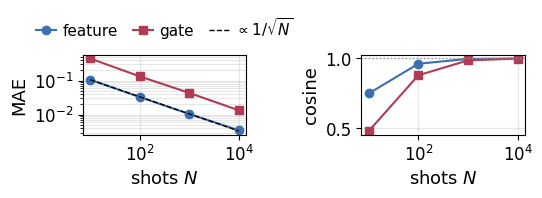

saved figures/fig_shots.png


In [6]:
# Figure fig_shots.png: (a) MAE vs N with 1/sqrt(N) reference; (b) cosine vs N
fig, (a1, a2) = plt.subplots(1, 2, figsize=(5.6, 2.2))
a1.loglog(SHOTS, feat["mae"], 'o-', color='#3b6fb0', label='feature')
a1.loglog(SHOTS, gate["mae"], 's-', color='#b03b54', label='gate')
a1.loglog(SHOTS, ref, 'k--', lw=1, label=r'$\propto 1/\sqrt{N}$')
a1.set_xlabel('shots $N$'); a1.set_ylabel('MAE')
a1.legend(frameon=False, loc='lower center', bbox_to_anchor=(0.5, 1.03), ncol=3, columnspacing=1.0, handlelength=1.3, handletextpad=0.4); a1.grid(alpha=0.3, which='both')

a2.semilogx(SHOTS, feat["cos"], 'o-', color='#3b6fb0', label='feature')
a2.semilogx(SHOTS, gate["cos"], 's-', color='#b03b54', label='gate')
a2.axhline(1.0, color='0.6', ls=':', lw=1)
a2.set_xlabel('shots $N$'); a2.set_ylabel('cosine')

a2.grid(alpha=0.3, which='both')
fig.tight_layout()
savefig(fig, 'fig_shots.png')
plt.show()
print("saved figures/fig_shots.png")

In [7]:
res = {
    "task": "shot-noise robustness (feature + gate)",
    "shots": SHOTS, "repeats": R,
    "feature": {"mae": feat["mae"], "cosine": feat["cos"], "spearman": feat["sp"],
                "d": D, "M": int(Mf)},
    "gate": {"mae": gate["mae"], "cosine": gate["cos"], "spearman": gate["sp"],
             "m": game.n, "M": int(Mg)},
    "loglog_slope": {"feature": slope_f, "gate": slope_g},
    "sqrtN_ok": bool(-0.62 < slope_f < -0.38 and -0.62 < slope_g < -0.38),
}
save_results("04", res)
print("saved results/04.json")

saved results/04.json


In [8]:
# Verification: MAE decays ~1/sqrt(N); cosine/rank improve toward 1
assert feat["mae"][-1] < feat["mae"][0] and gate["mae"][-1] < gate["mae"][0]
assert -0.62 < slope_f < -0.38, f"feature slope {slope_f:.3f} not ~ -0.5"
assert -0.62 < slope_g < -0.38, f"gate slope {slope_g:.3f} not ~ -0.5"
print(f"PASS  1/sqrt(N) decay confirmed: slopes feature={slope_f:.3f}, gate={slope_g:.3f}.")
print(f"      feature cosine {feat['cos'][0]:.3f}->{feat['cos'][-1]:.3f}; "
      f"gate cosine {gate['cos'][0]:.3f}->{gate['cos'][-1]:.3f}.")
print(f"      feature Spearman {feat['sp'][0]:.3f}->{feat['sp'][-1]:.3f}; "
      f"gate Spearman {gate['sp'][0]:.3f}->{gate['sp'][-1]:.3f}.")

PASS  1/sqrt(N) decay confirmed: slopes feature=-0.494, gate=-0.504.
      feature cosine 0.749->1.000; gate cosine 0.480->0.999.
      feature Spearman 0.620->0.965; gate Spearman 0.401->0.991.
